<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-03-19 02:20:27--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  48.1MB/s    in 4.2s    

2026-03-19 02:20:31 (48.5 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 176.6 MB/s eta 0:00:00


In [ ]:
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 162.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 149.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 174.4 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


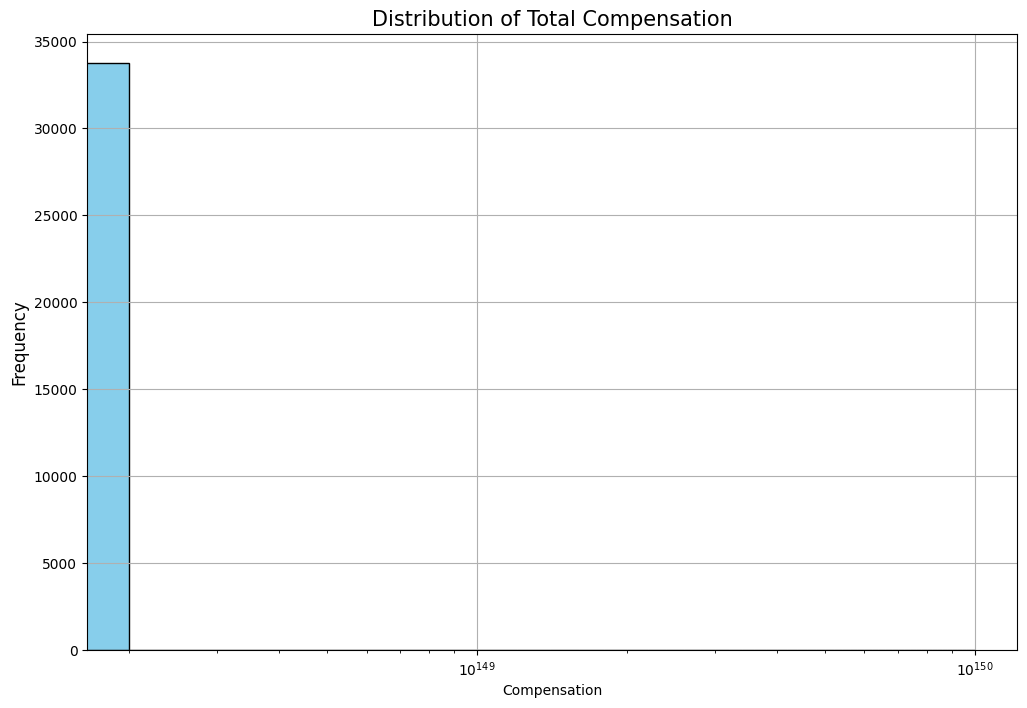

CompTotal     1.000000e+150
ResponseId     6.543200e+04
dtype: float64

In [ ]:
## Write your code here

#Select the data of interest from SQL
QUERY = """
SELECT CompTotal FROM main
    WHERE CompTotal IS NOT NULL
    AND CompTotal !='';
"""
df_comptotal = pd.read_sql_query(QUERY, conn)

#calculate first (25%) and third (75%) quartiles for ConvertedCompYearly
Q1 = df_comptotal['CompTotal'].quantile(0.25)
Q3 = df_comptotal['CompTotal'].quantile(0.75)
print(f'Yearly comp 25th percentile is {Q1}, and 75th percentile is {Q3}')

#calculate Interquartile Range (IQR) for ConvertedCompYearly
IQR = Q3-Q1
print(f'Yearly comp 25th Interquartile Range is {IQR}')

#Determine upper and lower bounds for outliers
#Tukey's Fences outlier is any value 1.5 times the IQR above Q3 or below Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Any compensation above ${upper_bound} or below ${lower_bound} is a statistical outlier')

#make a new dataframe by filtering, keeping only rows that fall within upper and lower bounds
df_no_outliers = df_comptotal[(df_comptotal['CompTotal'] >= lower_bound) & 
                    (df_comptotal['CompTotal'] <= upper_bound)]


#Plot a histogram 
plt.figure(figsize= (12,8))

ax = df_no_outliers['CompTotal'].hist(bins=50, edgecolor='black', color='skyblue')

#Define labels and title
plt.title('Distribution of Total Compensation', fontsize=15)
plt.xlabel('Compensation')
plt.ylabel('Frequency', fontsize=12)

plt.show()



**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [ ]:
## Write your code here
import numpy as np

QUERY = """
SELECT YearsCodePro, ResponseId
FROM main 
"""
df_years = pd.read_sql_query(QUERY, conn)

# clean data so nan's are removed
df_years_cleaned = df_years.dropna(subset=['YearsCodePro'])
df_years_cleaned['YearsCodePro'].unique()

#Use dictionary to change some df strings to numbers
df_years_cleaned['YearsCodePro'] = df_years_cleaned['YearsCodePro'].replace({
    'Less than 1 year': 0, 
    'More than 50 years': 51
})

# clean data so COmpTotal converted from string to float
df_years_cleaned['YearsCodePro']= pd.to_numeric(df_years_cleaned['YearsCodePro'])

#create bins from minimum to maximum values
bins = np.linspace(df_years_cleaned.min(), df_years_cleaned.max(), 20) 

#Plot a histogram 
plt.figure(figsize= (12,8))

ax = df_years_cleaned['YearsCodePro'].hist(bins=50, edgecolor='black', color='salmon')


#Define labels and title
plt.title('Distribution of Years of Coding', fontsize=15)
plt.xlabel('Years of Coding')
plt.ylabel('Frequency', fontsize=12)

plt.show()
df_years_cleaned.max()



### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [ ]:
## Write your code here
import seaborn as sns

#Select the data of interest from SQL
QUERY = """
SELECT CompTotal, Age FROM main
    WHERE CompTotal IS NOT NULL
    AND CompTotal !=''
    AND Age IS NOT NULL
    AND Age != '' ;
"""
df_comp_age = pd.read_sql_query(QUERY, conn)

#calculate first (25%) and third (75%) quartiles for ConvertedCompYearly
Q1 = df_comp_age['CompTotal'].quantile(0.25)
Q3 = df_comp_age['CompTotal'].quantile(0.75)
print(f'Yearly comp 25th percentile is {Q1}, and 75th percentile is {Q3}')

#calculate Interquartile Range (IQR) for ConvertedCompYearly
IQR = Q3-Q1
print(f'Yearly comp 25th Interquartile Range is {IQR}')

#Determine upper and lower bounds for outliers
#Tukey's Fences outlier is any value 1.5 times the IQR above Q3 or below Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Any compensation above ${upper_bound} or below ${lower_bound} is a statistical outlier')

#make a new dataframe by filtering, keeping only rows that fall within upper and lower bounds
df_compage_no_outliers = df_comp_age[(df_comp_age['CompTotal'] >= lower_bound) & 
                    (df_comp_age['CompTotal'] <= upper_bound)]

# define age order
age_order = [
    'Under 18 years old', 
    '18-24 years old', 
    '25-34 years old', 
    '35-44 years old', 
    '45-54 years old', 
    '55-64 years old', 
    '65 years or older'
]

#Plot a histogram 
plt.figure(figsize= (12,8))

sns.histplot(data=df_compage_no_outliers, x='CompTotal', hue= 'Age', 
             hue_order=age_order, kde=True, element = 'step')

#Define labels and title
plt.title('Distribution of Total Compensation by Age Group', fontsize=15)
plt.xlabel('Compensation')
plt.ylabel('Frequency', fontsize=12)
plt.show()


**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [ ]:
## Write your code here
import seaborn as sns

#Select the data of interest from SQL
QUERY = """
SELECT TimeSearching, Age, ResponseId FROM main
    WHERE TimeSearching IS NOT NULL
    AND TimeSearching !=''
    AND Age IS NOT NULL
    AND Age != '' ;
"""
df_age_time = pd.read_sql_query(QUERY, conn)

df_age_time['TimeSearching'].unique()

#Define the numeric time searching based on 'TimeSearching' answers
time_mapping = {
    '30-60 minutes a day': 45,
    '15-30 minutes a day': 37.5,
    '60-120 minutes a day': 90,
    'Less than 15 minutes a day': 10,
    'Over 120 minutes a day': 145,
}

# Apply the mapping to create a new numeric column
df_age_time['Minutes_Searching'] = df_age_time['TimeSearching'].map(time_mapping)


# define age order
age_order = [
    'Under 18 years old', 
    '18-24 years old', 
    '25-34 years old', 
    '35-44 years old', 
    '45-54 years old', 
    '55-64 years old', 
    '65 years or older'
]

#Plot a histogram 
plt.figure(figsize= (12,8))

sns.histplot(data=df_age_time, x='Minutes_Searching', hue= 'Age', 
             hue_order=age_order, kde=True, element = 'step')

#Define labels and title
plt.title('Distribution of Time Searching by Age Group', fontsize=15)
plt.xlabel('Minutes Searching')
plt.ylabel('Frequency', fontsize=12)
plt.show()


### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


In [ ]:
## Write your code here

#Select the data of interest from SQL
QUERY = """
SELECT DatabaseWantToWorkWith FROM main
    WHERE DatabaseWantToWorkWith IS NOT NULL
    AND DatabaseWantToWorkWith !='' ;
"""
df_future_learning = pd.read_sql_query(QUERY, conn)

df_future_learning['DatabaseWantToWorkWith'].unique()

#Change want to work with languages into counts
want = df_future_learning[['DatabaseWantToWorkWith']].copy()
want['Database'] = want['DatabaseWantToWorkWith'].str.split(';')
want_exploded = want.explode('Database')
want_counts = want_exploded['Database'].value_counts()

top_5_database = want_counts.head(5)
top_5_df = top_5_database.reset_index()
top_5_df.columns=['Database','Count']

# Plot the top 5 with a histogram
plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_df, x='Database', y='Count', hue='Database',  legend=True)

# Add labels
plt.title('Top 5 Most Desired Databases for Future Learning', fontsize=15)
plt.xlabel('Database Name')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)

plt.show()


**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [ ]:
## Write your code here

#Select the data of interest from SQL
QUERY = """
SELECT RemoteWork, ResponseId FROM main
    WHERE RemoteWork IS NOT NULL
    AND RemoteWork !='';
"""
df_work = pd.read_sql_query(QUERY, conn)

df_work['RemoteWork'].unique()
df_work.head()


#Plot a histogram 
plt.figure(figsize= (12,8))

sns.histplot(data=df_work, x='RemoteWork', edgecolor='black')

#Define labels and title
plt.title('Distribution of Remote Work', fontsize=15)
plt.xlabel('Remote Work Responses')
plt.ylabel('Frequency', fontsize=12)
plt.show()



### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


In [ ]:
## Write your code here

#Select the data of interest from SQL
QUERY = """
SELECT CompTotal, Age FROM main
    WHERE (Age = '45-54 years old' OR Age= '55-64 years old')
    AND CompTotal !=''
    AND CompTotal IS NOT NULL
    AND Age IS NOT NULL
    AND Age != '' ;
"""
df_comp_age = pd.read_sql_query(QUERY, conn)

#calculate first (25%) and third (75%) quartiles for ConvertedCompYearly
Q1 = df_comp_age['CompTotal'].quantile(0.25)
Q3 = df_comp_age['CompTotal'].quantile(0.75)
print(f'Yearly comp 25th percentile is {Q1}, and 75th percentile is {Q3}')

#calculate Interquartile Range (IQR) for ConvertedCompYearly
IQR = Q3-Q1
print(f'Yearly comp 25th Interquartile Range is {IQR}')

#Determine upper and lower bounds for outliers
#Tukey's Fences outlier is any value 1.5 times the IQR above Q3 or below Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Any compensation above ${upper_bound} or below ${lower_bound} is a statistical outlier')

#make a new dataframe by filtering, keeping only rows that fall within upper and lower bounds
df_compage_no_outliers = df_comp_age[(df_comp_age['CompTotal'] >= lower_bound) & 
                    (df_comp_age['CompTotal'] <= upper_bound)]

#Plot a histogram 
plt.figure(figsize= (12,8))

sns.histplot(data=df_compage_no_outliers, x='CompTotal', hue= 'Age', 
            kde=True, element = 'step')

#Define labels and title
plt.title('Distribution of Total Compensation by Age Group', fontsize=15)
plt.xlabel('Compensation')
plt.ylabel('Frequency', fontsize=12)
plt.show()


**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [ ]:
## Write your code here

#Select the data of interest from SQL
QUERY = """
SELECT JobSat, YearsCodePro FROM main
    WHERE YearsCodePro !=''
    AND YearsCodePro IS NOT NULL
    AND JobSat IS NOT NULL
    AND JobSat != '' ;
"""
df_jobsat = pd.read_sql_query(QUERY, conn)

df_jobsat['YearsCodePro'].unique()

#Need to convert strings to numbers b/c YearsCodePro uses strings and 'less than 1 year' or 'more than 50 years'
unique_vals = df_jobsat['YearsCodePro'].unique()
print(unique_vals)

#Use dictionary to change some df strings to numbers
df_jobsat['YearsCodePro'] = df_jobsat['YearsCodePro'].replace({
    'Less than 1 year': 0, 
    'More than 50 years': 51
})

#Convert all rest of YearsCodePro to numeric 
df_jobsat['YearsCodePro'] = pd.to_numeric(df_jobsat['YearsCodePro'])

#define bins and labels for years of coding experience categories
bins = [0, 2, 5, 15, 30, 100]
labels = ['Junior (0-2y)', 'Intermediate (2-5y)', 'Senior (5-15y)', 'Lead/Staff (15-30y)', 'Expert (30y+)']

# apply categorization to datafram
df_jobsat['Experience'] = pd.cut(df_jobsat['YearsCodePro'], bins=bins, labels=labels)

#Plot a histogram 
plt.figure(figsize= (12,8))

sns.histplot(data=df_jobsat, x='JobSat', hue= 'Experience', 
            kde=True, element = 'step')

#Define labels and title
plt.title('Distribution of Job Satisfaction by Years of Coding Experience', fontsize=15)
plt.xlabel('Job Satisfaction')
plt.ylabel('Frequency', fontsize=12)
plt.show()

#Plot a histogram 
plt.figure(figsize= (12,8))

sns.histplot(data=df_jobsat, x='YearsCodePro', hue= 'JobSat', 
            kde=True, element = 'step')

#Define labels and title
plt.title('Distribution of Job Satisfaction by Years of Coding Experience', fontsize=15)
plt.xlabel('Years of Coding Experience')
plt.ylabel('Frequency', fontsize=12)
plt.show()



### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
